# Minigrad

In [7]:
# utils

import base64
import difflib
from IPython.display import HTML, Image, display


def show_diff(old_code, new_code):
    """
    Compares old and new code, generating a beautifully styled, tightly spaced
    GitHub-like inline diff directly inside Google Colab.
    """
    old_lines = old_code.strip().splitlines()
    new_lines = new_code.strip().splitlines()

    diff = difflib.ndiff(old_lines, new_lines)

    # Using margin: 0 and line-height: 1.3 for code-editor spacing
    html_lines = [
        '<pre style="background-color: #1e1e1e; color: #d4d4d4; padding: 12px; '
        'border-radius: 6px; font-family: \'Fira Code\', Consolas, monospace; '
        'font-size: 13px; line-height: 1.3; overflow-x: auto; margin: 0;">'
    ]

    for line in diff:
        # We escape '<' and '>' so actual HTML in your code doesn't break the renderer
        safe_line = line.replace('<', '&lt;').replace('>', '&gt;')

        if line.startswith('- '):
            style = "background-color: #3b1e1e; color: #f14c4c; display: block; width: 100%; padding: 2px 5px; margin: 0; box-sizing: border-box;"
            html_lines.append(f'<span style="{style}">{safe_line}</span>')
        elif line.startswith('+ '):
            style = "background-color: #1e3b1e; color: #23d160; display: block; width: 100%; padding: 2px 5px; margin: 0; box-sizing: border-box;"
            html_lines.append(f'<span style="{style}">{safe_line}</span>')
        elif line.startswith('? '):
            continue
        else:
            style = "display: block; width: 100%; padding: 2px 5px; margin: 0; box-sizing: border-box;"
            html_lines.append(f'<span style="{style}">{safe_line}</span>')

    html_lines.append('</pre>')

    # FIX: Joining with an empty string ('') instead of newlines ('\n')
    # to stop the <pre> tag from creating double-spacing.
    display(HTML(''.join(html_lines)))


def draw_mermaid(mermaid_code):
    """Renders a Mermaid diagram in Google Colab."""
    graph_bytes = mermaid_code.encode("ascii")
    base64_bytes = base64.b64encode(graph_bytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))

This is a simplified version of PyTorch autograd.

It follows the same philosophy as Karpathy's [micrograd](https://www.youtube.com/watch?v=VMj-3S1tku0), but gets closer to real PyTorch in two ways: **(i) it closely follows PyTorch's API** (two classes: one for data and one for logic), and **(ii) it supports numpy inputs**.

Those two additions brings a new set of *gotchas*, and are a great way to  understand Autograd more deeply.

## High level API
Similar to PyTorch, it uses two base classes:
* `Data` to stores the data and it's gradient. It is also the object from which we call `backward()`.
* `Function` to store the foward and backward logic of each operation


Here is a description of the API, and its comparison with PyTorch:
| minigrad | PyTorch | Description |
| --- | --- | --- |
| **Data** | **Tensor** | Holds the data nodes |
| ↳ .data | .data | the actual data |
| ↳ .requires_grad | .requires_grad | Whether we need to keep track of the gradient for this node (e.g., no need for input data)
| ↳ .grad | .grad | Stores the computed gradient (populated by `.backward()`)
| ↳ .backward() | .backward() | Computes gradients based on the computational graph |
| ↳ .grad_fn | .grad_fn | Maps to the Function instance that created this Data instance |
| | | |
| **Function** | **torch.autograd.Function** | Defines operations and their gradients |
| ↳ .forward() | .forward() | Computes output and saves context |
| ↳ .backward() | .backward() | Computes gradients for inputs |
| ↳ .save_for_backward() | ctx.save_for_backward() | Saves intermediate values for backward pass |
| ↳ .apply() | .apply() | Creates a new instance of the Class and call forward |
| ↳ .parents | n/a | Links to the Data instances that are parents of this Function instance |

The two classes `Data` and `Function` are then combined together in high-level classes that are easier to manipulate for building a real model.

| minigrad | PyTorch | Description |
| --- | --- | --- |
| **Layer** | **torch.nn.Module** | Base class for all neural network modules |
| ↳ Linear | torch.nn.Linear | A linear layer (fully connected layer) |
| ↳ MLP | torch.nn.Sequential / Custom `torch.nn.Module` | Multi-layer Perceptron |
| | | |
| **Activation Functions** | **torch.nn.functional** | Common non-linearities |
| ↳ ReLu | torch.nn.ReLU / F.relu | Rectified Linear Unit |
| ↳ Softmax | torch.nn.Softmax / F.softmax | Softmax function |
| | | |
| **Loss Functions** | **torch.nn** | Functions to quantify prediction error |
| ↳ CrossEntropy | torch.nn.CrossEntropyLoss | Cross-entropy loss for classification |
| | | |
| **SGD** | **torch.optim.SGD** | Implements stochastic gradient descent optimizer |

## Main take-aways and *gotchas*

Implementing minigrad was much more challenging than I originally thought. Here are the key tips and learnings:

### A *lot* happens when we do a simple operation like `Y = X @ W`
We instantiate a new matrix multiply object, save the activations,  perform the forward, and instantiate a new data object. So much packed in a one liner! See section #1.2

### The .backward() accumulates gradients in the leaves only
Main points for the backward():
* The backpropagation happens in the opposite order of the topological sort of the forward.
* The gradients accumulate in the leaves, which means that we sum the gradients rather that overwritting them
* When we run `.backward()` two times, the gradients accumulate *in the leaves only*: the gradient of the intermediate nodes is discarded.

See sections #2.2 and #2.3

### Any broadcast during the forward should be unbroadcast during the backward

Numpy automatically broadcasts arrays during the forward (e.g., the bias term of a linear layer), so we need to correctly unbroadcast them during the backward. See section #2.4.

### `Layers` find their parameters using recursive search
To find the learnable parameters of a `Layers`, we can recursively search among its parameters. See section #3.

## The output: a fully functional learning engine

Once all of this is done, we get a fully functional autograd. See part #3.

# 1. Base classes

PyTorch Autograd works around two main base classes: `Tensor` and `Function`. We follow a similar approach: our base classes are `Data` and `Function`.

We keep track of the computation graph by linking the instances: each `Function` keeps track of its input `Data` instances, and vice-versa.

In [2]:
import base64
from IPython.display import Image, display

def draw_mermaid(mermaid_code):
    """Renders a Mermaid diagram in Google Colab."""
    graph_bytes = mermaid_code.encode("ascii")
    base64_bytes = base64.b64encode(graph_bytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))

diagram = """
graph LR
    x["x (Data) - Input \ndata: 2.0\ngrad_fn: None"]
    y["y (Data) - Input\ndata: 3.0\ngrad_fn: None"]
    Mul["Mul (Function) - Operation \nparents: [x, y]\n_saved: (2.0, 3.0)"]
    z["z (Data) - Output\ndata: 6.0\ngrad_fn: Mul"]

    x --> Mul
    y --> Mul
    Mul --> z

    Mul <-.- z
    x <-.- Mul
    y <-.- Mul
"""

draw_mermaid(diagram)

## 1.1. `Data`

The base implementation of **Data** is relatively simple.

In [3]:
import numpy as np

# class definition
class Data:
  def __init__(self, data: np.ndarray, requires_grad: bool = False, grad_fn: 'Function' = None):
    self.data = data
    self.grad: np.ndarray | None = None
    self.requires_grad = requires_grad
    self.grad_fn = grad_fn

  def __repr__(self) -> str:
    return f"Data(data={self.data}, grad={self.grad}, requires_grad={self.requires_grad}, grad_fn={self.grad_fn})"

  def backward(self) -> None:
    raise NotImplementedError() # we will complete this in section #2

  # --- ops: we will add all the operations below in section #1.2 and #1.3 ---
  def __matmul__(self, other: 'Data') -> 'Data':
    raise NotImplementedError()

## 1.2. `Function` - start with `MatMul` example

The implementation of `Function` is a bit more involved.

In this section we will show the idea of its implementation for a matrix multiplication; in the next section (#1.3.) we will implement the general case.

Let's consider a simple matrix multiplication:
```python
a = Data(np.array([1]), requires_grad=True)
b = Data(np.array([2]), requires_grad=True)
c = a @ b
```

**A lot is happening** behind the simple line `c = a @ b`:
1. A new instance of the class `Function` is created. We need a new instance, because we need to store specific attributes from *this* multiplication (e.g., the activations).
2. We save the specific *inputs* of the Function (so we know where to propagate the gradient during the backward), and the *activations* (to compute the backward).
3. We compute the forward
4. We create a new Tensor (called `Data` in this implementation) that contains the result of the matrix multiplication, and a reference to the function that created it.

**Let's break-down all those steps in pseudo-code:**
```python
a = Data([1], requires_grad=True)
b = Data([2], requires_grad=True)

# (1) create new instance of multiplication
mat_mul_instance = MatMul()
# (2) save the parents
mat_mul_instance.parents=[a, b]
# save activations for the backward
mat_mul_instance.save_for_backward(b, a)
# create a new tensor
out_data = mat_mul_instance.forward(a.data, b.data)
c = Data([out_data], requires_grad=True, grad_fn=mat_mul_instance)
```

That's clearer for a breakdown, but it's a lot to write everytime we make a multiplication! We can **make it more user-friendly** by doing the following:

1. Build a wrapper **`apply()`** that contains the **creation of the new instances `Function` and `Data`**.

In [4]:
class MatMul:
  def __init__(self):
    self.parents = []

  def save_for_backward(self, *args: np.ndarray):
    self._saved = args

  @staticmethod
  def forward(ctx, a: np.ndarray, b: np.ndarray):
    ctx.save_for_backward(b.data, a.data) # we save the activation
    return a @ b

  @staticmethod
  def backward(cls, grad_in):
    raise NotImplementedError() # we will complete that in the next section

  @classmethod
  def apply(cls, a, b):
    ctx = cls() # cls() is Python for creating a new instance of the class - so ctx is an instance of MatMul that we just created
    ctx.parents = [a, b] # we save the parents of the newly created instance
    out_data = ctx.forward(ctx, a.data, b.data) # compute the data for output
    requires_grad = a.requires_grad or b.requires_grad
    return Data(out_data, grad_fn=ctx, requires_grad=requires_grad) # return a Data object

  def __repr__(self):
    return f"MatMul_{id(self)}"


# we call it as such:
a = Data(np.array([1]), requires_grad=True)
b = Data(np.array([2]), requires_grad=True)
c = MatMul.apply(a, b) # this single line creates two instances, one of the data (`c`), and one of the MatMul
print(f"c: {c}")

# under-the-hood this created a new matmul instance, which we can access through `.grad_fn` on `c`
print(f"\n MatMul instance: {c.grad_fn}")

c: Data(data=2, grad=None, requires_grad=True, grad_fn=MatMul_4454073152)

 MatMul instance: MatMul_4454073152


2. **Wrap `apply()` in a symbol** so we can do `c = a @ b` instead of `c = MatMul.apply(a, b)`. To do so, we add the method `__matmul__` to the data:

In [8]:
old_data_code = """
class Data:
  def __init__(self, data: np.ndarray, requires_grad: bool = False, grad_fn: 'Function' = None):
    self.data = data
    self.grad: np.ndarray | None = None
    self.requires_grad = requires_grad
    self.grad_fn = grad_fn

  def __repr__(self) -> str:
    return f"Data(data={self.data}, grad={self.grad}, requires_grad={self.requires_grad}, grad_fn={self.grad_fn})"

  def backward(self) -> None:
    raise NotImplementedError()

  def __matmul__(self, other: 'Data') -> 'Data':
    raise NotImplementedError()
"""

new_data_code = """
class Data:
  def __init__(self, data: np.ndarray, requires_grad: bool = False, grad_fn: 'Function' = None):
    self.data = data
    self.grad: np.ndarray | None = None
    self.requires_grad = requires_grad
    self.grad_fn = grad_fn

  def __repr__(self) -> str:
    return f"Data(data={self.data}, grad={self.grad}, requires_grad={self.requires_grad}, grad_fn={self.grad_fn})"

  def backward(self) -> None:
    raise NotImplementedError()

  def __matmul__(self, other: 'Data') -> 'Data':
    return MatMul.apply(self, other)
"""

exec(new_data_code)

show_diff(old_data_code, new_data_code)

Let's test it on a simple example:

In [9]:
# we can now call it as such
a = Data(np.array([1]), requires_grad=True)
b = Data(np.array([2]), requires_grad=True)
c = a @ b # this single line creates two instances, one of the data (`c`), and one of the MatMul
print(f"c: {c}")

c: Data(data=2, grad=None, requires_grad=True, grad_fn=MatMul_4547299600)


## 1.3. Extend to more operations - and run the forward on an MLP

So far we saw only the example of MatMul, but we need much more operations. All of those will share the same base methods (e.g., `save_for_backward`, `apply`) and only differ by their implementation of `forward` and `backward`. So we create a base class `Function` from which they inherit.

In [10]:
import numpy as np
from typing import Tuple, List, Any, Union

# -------
# This defines the base class
# -------
class Function:
  def __init__(self):
    self.parents: List['Data'] = []
    self._saved: Tuple[Any, ...] = ()

  def save_for_backward(self, *tensors: Any):
    self._saved = tensors

  @staticmethod
  def forward(ctx: Any, *args: np.ndarray, **kwargs: Any) -> np.ndarray:
    raise NotImplementedError() # should be implemented by the child class

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray, ...]:
    raise NotImplementedError() # should be implemented by the child class

  @classmethod
  def apply(cls, *args: 'Data', **kwargs: Any) -> 'Data':
    # args are data, kwargs are extra parameters, like the exponent in a power

    # create instance of operator
    operation_instance = cls()
    operation_instance.parents = list(args)
    # operation_instance.save_for_backward() # save_for_backward is now called inside the forward method of each specific Function

    # create Data to be returned
    data_out = operation_instance.forward(operation_instance, *[arg.data for arg in args], **kwargs)
    requires_grad = any([arg.requires_grad for arg in args])
    return Data(data_out, requires_grad=requires_grad, grad_fn=operation_instance)


# -------
# Below are the sub classes (only the forwards for now)
# -------
class MatMul(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a @ b

class Add(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a,b)
    return a + b

class Sub(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a,b)
    return a - b

class Mul(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a * b

class Div(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a / b

class Neg(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return -a

class Pow(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, exponent: int) -> np.ndarray:
    ctx.save_for_backward(a)
    ctx.exponent = exponent
    return a**exponent

class Exp(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.exp(a)

class Log(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.log(a)

class ReLu(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.maximum(a, 0)

class Sum(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> np.ndarray:
    ctx.in_shape = a.shape
    ctx.axis = axis
    ctx.keepdims = keepdims
    return a.sum(axis=axis, keepdims=keepdims)

class Mean(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> np.ndarray:
    ctx.in_shape = a.shape
    ctx.axis = axis
    ctx.keepdims = keepdims
    return a.mean(axis=axis, keepdims=keepdims)

class Reshape(Function):
  @staticmethod
  def forward(ctx: Any, x: np.ndarray, shape: Tuple[int, ...]) -> np.ndarray:
    ctx.in_shape = x.shape
    return x.reshape(shape)

class Transpose(Function):
  @staticmethod
  def forward(ctx: Any, x: np.ndarray) -> np.ndarray:
    return x.T

We also add the symbols to the Data class

In [11]:
old_data_code = new_data_code

new_data_code = """
class Data:
  def __init__(self, data: np.ndarray, requires_grad: bool = False, grad_fn: 'Function' = None):
    self.data = data
    self.grad: np.ndarray | None = None
    self.requires_grad = requires_grad
    self.grad_fn = grad_fn

  def __repr__(self) -> str:
    return f"Data(data={self.data}, grad={self.grad}, requires_grad={self.requires_grad}, grad_fn={self.grad_fn})"

  def backward(self) -> None:
    raise NotImplementedError()

  def __add__(self, other: 'Data') -> 'Data':
    return Add.apply(self, other)

  def __radd__(self, other: 'Data') -> 'Data':
    return Add.apply(other, self)

  def __matmul__(self, other: 'Data') -> 'Data':
    return MatMul.apply(self, other)

  def __sub__(self, other: 'Data') -> 'Data':
    return Sub.apply(self, other)

  def __rsub__(self, other: 'Data') -> 'Data':
    return Sub.apply(other, self)

  def __mul__(self, other: 'Data') -> 'Data':
    return Mul.apply(self, other)

  def __rmul__(self, other: 'Data') -> 'Data':
    return Mul.apply(other, self)

  def __truediv__(self, other: 'Data') -> 'Data':
    return Div.apply(self, other)

  def __rtruediv__(self, other: 'Data') -> 'Data':
    return Div.apply(other, self)

  def __neg__(self) -> 'Data':
    return Neg.apply(self)

  def __pow__(self, exponent: int) -> 'Data':
    return Pow.apply(self, exponent=exponent)

  def exp(self) -> 'Data':
    return Exp.apply(self)

  def log(self) -> 'Data':
    return Log.apply(self)

  def relu(self) -> 'Data':
    return ReLu.apply(self)

  def sum(self, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> 'Data':
    return Sum.apply(self, axis=axis, keepdims=keepdims)

  def mean(self, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> 'Data':
    return Mean.apply(self, axis=axis, keepdims=keepdims)

  def reshape(self, shape: Tuple[int, ...]) -> 'Data':
    return Reshape.apply(self, shape=shape)

  @property
  def T(self) -> 'Data':
    return Transpose.apply(self)
"""

exec(new_data_code)

show_diff(old_data_code, new_data_code)

Test on the forward of an MLP:

In [12]:
# Implementing the forward for an MLP

# dimenssions
batch = 50
dim_in = 10
dim_hidden = 20

# data
X = Data(data=np.random.rand(50, dim_in))
label = Data(data=np.random.rand(50, 1))

# weights and bias
W1 = Data(data=np.random.rand(dim_hidden, dim_in), requires_grad=True)
b1 = Data(data=np.random.rand(1, 1), requires_grad=True)

W2 = Data(data=np.random.rand(1, dim_hidden), requires_grad=True)
b2 = Data(data=np.random.rand(1, 1), requires_grad=True)

# forward
Z = ReLu.apply(X @ W1.T + b1)
Y_hat = Z @ W2.T + b2

# loss
loss = ((Y_hat - label) ** 2).mean()

assert(
    loss.data == np.mean((np.maximum(X.data @ W1.data.T + b1.data, 0) @ W2.data.T + b2.data - label.data)**2)
)

/var/folders/20/46qs1_rs7075nzdrqxknqd_c0000gn/T/ipykernel_6341/3247833080.py:45: RuntimeWarning: divide by zero encountered in matmul
  return a @ b
/var/folders/20/46qs1_rs7075nzdrqxknqd_c0000gn/T/ipykernel_6341/3247833080.py:45: RuntimeWarning: overflow encountered in matmul
  return a @ b
/var/folders/20/46qs1_rs7075nzdrqxknqd_c0000gn/T/ipykernel_6341/3247833080.py:45: RuntimeWarning: invalid value encountered in matmul
  return a @ b
/var/folders/20/46qs1_rs7075nzdrqxknqd_c0000gn/T/ipykernel_6341/3856742774.py:27: RuntimeWarning: divide by zero encountered in matmul
  loss.data == np.mean((np.maximum(X.data @ W1.data.T + b1.data, 0) @ W2.data.T + b2.data - label.data)**2)
/var/folders/20/46qs1_rs7075nzdrqxknqd_c0000gn/T/ipykernel_6341/3856742774.py:27: RuntimeWarning: overflow encountered in matmul
  loss.data == np.mean((np.maximum(X.data @ W1.data.T + b1.data, 0) @ W2.data.T + b2.data - label.data)**2)
/var/folders/20/46qs1_rs7075nzdrqxknqd_c0000gn/T/ipykernel_6341/3856742774.py

# 2. Backward

To run the backward, we need to add two main elements to our implementation so far:
1. The chain-rule logic on each function, that we will store in `backward`
2. The propagation of the chain-rule through the compute graph

## 2.1. Chain-rule logic

We implement `backward` for each class: they take a gradient in, and output as many gradients as they have inputs.

In [13]:
old_functions_code = """
class MatMul(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a @ b

class Add(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a,b)
    return a + b

class Sub(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a,b)
    return a - b

class Mul(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a * b

class Div(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a / b

class Neg(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return -a

class Pow(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, exponent: int) -> np.ndarray:
    ctx.save_for_backward(a)
    ctx.exponent = exponent
    return a**exponent

class Exp(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.exp(a)

class Log(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.log(a)

class ReLu(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.maximum(a, 0)

class Sum(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> np.ndarray:
    ctx.in_shape = a.shape
    ctx.axis = axis
    ctx.keepdims = keepdims
    return a.sum(axis=axis, keepdims=keepdims)

class Mean(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> np.ndarray:
    ctx.in_shape = a.shape
    ctx.axis = axis
    ctx.keepdims = keepdims
    return a.mean(axis=axis, keepdims=keepdims)

class Reshape(Function):
  @staticmethod
  def forward(ctx: Any, x: np.ndarray, shape: Tuple[int, ...]) -> np.ndarray:
    ctx.in_shape = x.shape
    return x.reshape(shape)

class Transpose(Function):
  @staticmethod
  def forward(ctx: Any, x: np.ndarray) -> np.ndarray:
    return x.T
"""

new_functions_code = """
class MatMul(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a @ b

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    a, b = ctx._saved
    return grad_in @ b.T, a.T @ grad_in

class Add(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a,b)
    return a + b

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    return grad_in, grad_in

class Sub(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a,b)
    return a - b

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    return grad_in, -grad_in

class Mul(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a * b

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    a, b = ctx._saved
    return grad_in * b, grad_in * a


class Div(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, b: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a, b)
    return a / b

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    a, b = ctx._saved
    return grad_in / b, - grad_in * a / b**2

class Neg(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return -a

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    return (-grad_in,)

class Pow(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, exponent: int) -> np.ndarray:
    ctx.save_for_backward(a)
    ctx.exponent = exponent
    return a**exponent

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    a = ctx._saved[0]
    return (grad_in * ctx.exponent * a ** (ctx.exponent - 1),)

class Exp(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.exp(a)

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    a = ctx._saved[0]
    return (grad_in * np.exp(a),)

class Log(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.log(a)

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    a = ctx._saved[0]
    return (grad_in / a,)

class ReLu(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray) -> np.ndarray:
    ctx.save_for_backward(a)
    return np.maximum(a, 0)

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    a = ctx._saved[0]
    return (grad_in * (a > 0),)

class Sum(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> np.ndarray:
    ctx.in_shape = a.shape
    ctx.axis = axis
    ctx.keepdims = keepdims
    return a.sum(axis=axis, keepdims=keepdims)

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    grad_in = np.asarray(grad_in, dtype=np.float64)
    if ctx.axis is not None and not ctx.keepdims:
      grad_in = np.expand_dims(grad_in, ctx.axis)
    return (np.broadcast_to(grad_in, ctx.in_shape).copy(),)

class Mean(Function):
  @staticmethod
  def forward(ctx: Any, a: np.ndarray, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> np.ndarray:
    ctx.in_shape = a.shape
    ctx.axis = axis
    ctx.keepdims = keepdims
    if axis is None:
      ctx.n = a.size
    else:
      axes = (axis,) if isinstance(axis, int) else tuple(axis)
      ctx.n = int(np.prod([a.shape[ax] for ax in axes]))
    return a.mean(axis=axis, keepdims=keepdims)

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    grad_in = np.asarray(grad_in, dtype=np.float64) / ctx.n
    if ctx.axis is not None and not ctx.keepdims:
      grad_in = np.expand_dims(grad_in, ctx.axis)
    return (np.broadcast_to(grad_in, ctx.in_shape).copy(),)

class Reshape(Function):
  @staticmethod
  def forward(ctx: Any, x: np.ndarray, shape: Tuple[int, ...]) -> np.ndarray:
    ctx.in_shape = x.shape
    return x.reshape(shape)

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    return (grad_in.reshape(ctx.in_shape), )

class Transpose(Function):
  @staticmethod
  def forward(ctx: Any, x: np.ndarray) -> np.ndarray:
    return x.T

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    return (grad_in.T,)
"""

exec(new_functions_code)

show_diff(old_functions_code, new_functions_code)

## 2.2. Topological sort

We need to get the order in which to run the backward: to do so we use [topoligical sort](https://en.wikipedia.org/wiki/Topological_sorting).

In [14]:
def get_topological_order(data_node: 'Data') -> List['Data']:
  topo_order: List['Data'] = []
  visited: Set['Data'] = set([])
  visiting: Set['Data'] = set([])

  def dfs(data_node: 'Data'):
    visiting.add(data_node)
    if data_node.grad_fn is None:
      topo_order.append(data_node)
      visiting.remove(data_node)
      visited.add(data_node)
      return

    for parent_node in data_node.grad_fn.parents:
      if parent_node in visiting:
        raise ValueError("Circular dependency found")
      if parent_node not in visited:
        dfs(parent_node)

    visited.add(data_node)
    topo_order.append(data_node)
    visiting.remove(data_node)
    return

  dfs(data_node)
  return topo_order


# testing
a = Data(np.array([1]), requires_grad=True)
b = Data(np.array([2]), requires_grad=True)
c = a + b
assert(get_topological_order(c) == [a, b, c] or get_topological_order(c) == [b, a, c])

## 2.3. Implementing the backward

We almost have all the pieces for the backward pass.

We need to keep in mind one thing that can trip us otherwise: **gradients accumulate in the leaves**.

Let's take this example: `x leaf, h = x * x (intermediate), loss = h.sum()`

```mermaid
graph TD
    X[x] --> H[h = x * x]
    H --> Loss[loss = h.sum()]
```

Here is what should happen when we run the backward one time:
```
loss.grad = 1 (initialisation)
h.grad = 1 (chain rule from the loss)
x.grad = x + x = 2.x (⚠️ gradients are accumulated, so it's 2.x, not x)
```

And if we run it a second time:
```
loss.grad = 1 (same as above)
h.grad = 1 (⚠️ we don't accumulate the gradients in the intermediate nodes, just in the nodes. So we get 1 again instead of 2)
x.grad = 2.x + 2.x = 4.x (⚠️ we accumulate the gradients in the leaves)
```

To respect the gradient accumulation in the leaves we do two things:
* We **add** gradient: `data.grad += incoming_grad`
* For intermediate nodes, we keep gradients in a temporary object that will be re-initialised when we call `backward()` again.

In [15]:
old_data_code = new_data_code

new_data_code = """
class Data:
  def __init__(self, data: np.ndarray, requires_grad: bool = False, grad_fn: 'Function' = None):
    self.data = data
    self.grad: np.ndarray | None = None
    self.requires_grad = requires_grad
    self.grad_fn = grad_fn

  def __repr__(self) -> str:
    return f"Data(data={self.data}, grad={self.grad}, requires_grad={self.requires_grad}, grad_fn={self.grad_fn})"

  def backward(self) -> None:
    raise NotImplementedError()

  def __add__(self, other: 'Data') -> 'Data':
    return Add.apply(self, other)

  def __radd__(self, other: 'Data') -> 'Data':
    return Add.apply(other, self)

  def __matmul__(self, other: 'Data') -> 'Data':
    return MatMul.apply(self, other)

  def __sub__(self, other: 'Data') -> 'Data':
    return Sub.apply(self, other)

  def __rsub__(self, other: 'Data') -> 'Data':
    return Sub.apply(other, self)

  def __mul__(self, other: 'Data') -> 'Data':
    return Mul.apply(self, other)

  def __rmul__(self, other: 'Data') -> 'Data':
    return Mul.apply(other, self)

  def __truediv__(self, other: 'Data') -> 'Data':
    return Div.apply(self, other)

  def __rtruediv__(self, other: 'Data') -> 'Data':
    return Div.apply(other, self)

  def __neg__(self) -> 'Data':
    return Neg.apply(self)

  def __pow__(self, exponent: int) -> 'Data':
    return Pow.apply(self, exponent=exponent)

  def exp(self) -> 'Data':
    return Exp.apply(self)

  def log(self) -> 'Data':
    return Log.apply(self)

  def relu(self) -> 'Data':
    return ReLu.apply(self)

  def sum(self, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> 'Data':
    return Sum.apply(self, axis=axis, keepdims=keepdims)

  def mean(self, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> 'Data':
    return Mean.apply(self, axis=axis, keepdims=keepdims)

  def reshape(self, shape: Tuple[int, ...]) -> 'Data':
    return Reshape.apply(self, shape=shape)

  @property
  def T(self) -> 'Data':
    return Transpose.apply(self)

  def backward(self):
    grad_dict = {}
    # Initialize the gradient for the start_node based on its data shape
    grad_dict[id(self)] = np.ones_like(self.data)

    for data_node in reversed(get_topological_order(self)):
      if not data_node.requires_grad: # no need to explore
        continue

      # If the current node is a leaf node, accumulate its gradient
      if data_node.requires_grad and not data_node.grad_fn:
        if data_node.grad is not None:
          data_node.grad += grad_dict[id(data_node)]
        else:
          data_node.grad = grad_dict[id(data_node)]
        continue

      # Pass down the gradient to parents
      data_node_grad = grad_dict[id(data_node)]
      grads_out = type(data_node.grad_fn).backward(data_node.grad_fn, data_node_grad)

      for grad_out, data_node_parent in zip(grads_out, data_node.grad_fn.parents):
        if data_node_parent.requires_grad:
          parent_id = id(data_node_parent)
          if parent_id in grad_dict:
            grad_dict[parent_id] += grad_out
          else:
            grad_dict[parent_id] = grad_out
    return
"""

exec(new_data_code)

show_diff(old_data_code, new_data_code)

In [16]:
# ---
x = Data(np.array([3]), requires_grad=True)
h = x * x
loss = h.sum()
# ---

print("-- before backward --")
print(loss)
print(h)
print(x)

print("\n -- after backward 1 --")
loss.backward()
print(loss)
print(h)
print(x)

print("\n -- after backward 2 --")
loss.backward()
print(loss)
print(h)
print(x)

-- before backward --
Data(data=9, grad=None, requires_grad=True, grad_fn=<__main__.Sum object at 0x10f27c5b0>)
Data(data=[9], grad=None, requires_grad=True, grad_fn=<__main__.Mul object at 0x10f27c1f0>)
Data(data=[3], grad=None, requires_grad=True, grad_fn=None)

 -- after backward 1 --
Data(data=9, grad=None, requires_grad=True, grad_fn=<__main__.Sum object at 0x10f27c5b0>)
Data(data=[9], grad=None, requires_grad=True, grad_fn=<__main__.Mul object at 0x10f27c1f0>)
Data(data=[3], grad=[6.], requires_grad=True, grad_fn=None)

 -- after backward 2 --
Data(data=9, grad=None, requires_grad=True, grad_fn=<__main__.Sum object at 0x10f27c5b0>)
Data(data=[9], grad=None, requires_grad=True, grad_fn=<__main__.Mul object at 0x10f27c1f0>)
Data(data=[3], grad=[12.], requires_grad=True, grad_fn=None)


## 2.4. Fixing the broadcast bug

There is, unfortunately, a hidden bug in the implementation of the backward. It is due to how numpy silently broadcasts the shapes in the forward, and doesn't undo the broadcast in the backward.

Let's take a simple linear example with the following sizes:
```
Shapes:
-------
X: (batch, dim_in)
W: (dim_out, dim_in)
b: (dim_out,)

Operation:
----------
y = X @ W.T + b
```

To make this sum, numpy transforms the shape of b to `(batch, dim_out)`; which means that the gradient coming from y to b is of shape `(batch, dim_out)`. Then, when we will take a step in the direction of the gradient, things will break:
```
Shapes:
-------
b: (dim_out,)
b.grad: (batch, dim_out)

Operation:
----------
b.data -= learning_rate * b.grad ⚠️ breaks because of shape mismatch
```

So we need to make sure that we **always unbroadcast** because saving a gradient. To unbroadcast, we need to find the dimensions that were added, and sum over them.

In [17]:
old_data_code = new_data_code

new_data_code = """
def unbroadcast(grad: np.ndarray, original_shape: Tuple[int, ...]) -> np.ndarray:
  while grad.ndim > len(original_shape):
    grad = grad.sum(axis=0)
  for i, dim in enumerate(original_shape):
    if dim == 1 and grad.shape[i] != 1:
      grad = grad.sum(axis=i, keepdims=True)
  return grad

class Data:
  def __init__(self, data: np.ndarray, requires_grad: bool = False, grad_fn: 'Function' = None):
    self.data = data
    self.grad: np.ndarray | None = None
    self.requires_grad = requires_grad
    self.grad_fn = grad_fn

  def __repr__(self) -> str:
    return f"Data(data={self.data}, grad={self.grad}, requires_grad={self.requires_grad}, grad_fn={self.grad_fn})"

  def backward(self) -> None:
    raise NotImplementedError()

  def __add__(self, other: 'Data') -> 'Data':
    return Add.apply(self, other)

  def __radd__(self, other: 'Data') -> 'Data':
    return Add.apply(other, self)

  def __matmul__(self, other: 'Data') -> 'Data':
    return MatMul.apply(self, other)

  def __sub__(self, other: 'Data') -> 'Data':
    return Sub.apply(self, other)

  def __rsub__(self, other: 'Data') -> 'Data':
    return Sub.apply(other, self)

  def __mul__(self, other: 'Data') -> 'Data':
    return Mul.apply(self, other)

  def __rmul__(self, other: 'Data') -> 'Data':
    return Mul.apply(other, self)

  def __truediv__(self, other: 'Data') -> 'Data':
    return Div.apply(self, other)

  def __rtruediv__(self, other: 'Data') -> 'Data':
    return Div.apply(other, self)

  def __neg__(self) -> 'Data':
    return Neg.apply(self)

  def __pow__(self, exponent: int) -> 'Data':
    return Pow.apply(self, exponent=exponent)

  def exp(self) -> 'Data':
    return Exp.apply(self)

  def log(self) -> 'Data':
    return Log.apply(self)

  def relu(self) -> 'Data':
    return ReLu.apply(self)

  def sum(self, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> 'Data':
    return Sum.apply(self, axis=axis, keepdims=keepdims)

  def mean(self, axis: Union[int, Tuple[int, ...], None] = None, keepdims: bool = False) -> 'Data':
    return Mean.apply(self, axis=axis, keepdims=keepdims)

  def reshape(self, shape: Tuple[int, ...]) -> 'Data':
    return Reshape.apply(self, shape=shape)

  @property
  def T(self) -> 'Data':
    return Transpose.apply(self)

  def backward(self):
    grad_dict = {}
    # Initialize the gradient for the start_node based on its data shape
    grad_dict[id(self)] = np.ones_like(self.data)

    for data_node in reversed(get_topological_order(self)):
      if not data_node.requires_grad: # no need to explore
        continue

      # If the current node is a leaf node, accumulate its gradient
      if data_node.requires_grad and not data_node.grad_fn:
        if data_node.grad is not None:
          data_node.grad += grad_dict[id(data_node)]
        else:
          data_node.grad = grad_dict[id(data_node)]
        continue

      # Pass down the gradient to parents
      data_node_grad = grad_dict[id(data_node)]
      grads_out = type(data_node.grad_fn).backward(data_node.grad_fn, data_node_grad)

      for grad_out, data_node_parent in zip(grads_out, data_node.grad_fn.parents):
        if data_node_parent.requires_grad:
          parent_id = id(data_node_parent)
          if parent_id in grad_dict:
            grad_dict[parent_id] += unbroadcast(grad_out, data_node_parent.data.shape)
          else:
            grad_dict[parent_id] = unbroadcast(grad_out, data_node_parent.data.shape)
    return
"""

exec(new_data_code)

show_diff(old_data_code, new_data_code)

In [18]:
# ---
x = Data(np.array([3]), requires_grad=True)
h = x * x
loss = h.sum()
# ---

print("-- before backward --")
print(loss)
print(h)
print(x)

print("\n -- after backward 1 --")
loss.backward()
print(loss)
print(h)
print(x)

print("\n -- after backward 2 --")
loss.backward()
print(loss)
print(h)
print(x)

-- before backward --
Data(data=9, grad=None, requires_grad=True, grad_fn=<__main__.Sum object at 0x10f65c5b0>)
Data(data=[9], grad=None, requires_grad=True, grad_fn=<__main__.Mul object at 0x10f65c910>)
Data(data=[3], grad=None, requires_grad=True, grad_fn=None)

 -- after backward 1 --
Data(data=9, grad=None, requires_grad=True, grad_fn=<__main__.Sum object at 0x10f65c5b0>)
Data(data=[9], grad=None, requires_grad=True, grad_fn=<__main__.Mul object at 0x10f65c910>)
Data(data=[3], grad=[6.], requires_grad=True, grad_fn=None)

 -- after backward 2 --
Data(data=9, grad=None, requires_grad=True, grad_fn=<__main__.Sum object at 0x10f65c5b0>)
Data(data=[9], grad=None, requires_grad=True, grad_fn=<__main__.Mul object at 0x10f65c910>)
Data(data=[3], grad=[12.], requires_grad=True, grad_fn=None)


In [19]:
# dims
batch = 64
dim_in = 10
dim_model = 16

# data
X = Data(np.random.random([batch, dim_in]), requires_grad=False)
y = X.sum(axis=1)

# model
W = Data(np.random.random([dim_model, dim_in]), requires_grad=True)
b = Data(np.zeros([dim_model]), requires_grad=True)

# forward
h = X @ W.T + b
loss = ((h.sum(axis=1) - y) ** 2).sum()

# backward
loss.backward()

# shape: expecting (16,)
b.grad.shape

<string>:6: RuntimeWarning: divide by zero encountered in matmul
<string>:6: RuntimeWarning: overflow encountered in matmul
<string>:6: RuntimeWarning: invalid value encountered in matmul
<string>:11: RuntimeWarning: divide by zero encountered in matmul
<string>:11: RuntimeWarning: overflow encountered in matmul
<string>:11: RuntimeWarning: invalid value encountered in matmul


(16,)

# Test!

In [20]:
# Gradient accumulation with an input is re-used
x = Data(np.random.uniform(low=-1, high=1, size=5), requires_grad=True)
(x * x).sum().backward()
actual_grad = x.grad
expected_grad = 2 * x.data
assert(np.allclose(actual_grad, expected_grad, atol=1e-8, rtol=1e-6))

# non-leaf reused
x = Data(np.random.uniform(low=-1, high=1, size=5), requires_grad=True)
a = x + x
(a * a).sum().backward()
actual_grad = x.grad
expected_grad = 8 * x.data
assert(np.allclose(actual_grad, expected_grad, atol=1e-8, rtol=1e-6))

In [21]:
import torch

# Test matmul with broadcasting (1)
X = Data(np.random.random(size=(6, 3)), requires_grad=True)
W = Data(np.random.random(size=(4, 3)), requires_grad=True)
b = Data(np.random.random(size=(4)), requires_grad=True)
(X @ W.T + b).sum().backward()

Xt, Wt, bt = (torch.tensor(z.data, requires_grad=True) for z in (X, W, b))
(Xt @ Wt.T + bt).sum().backward()

assert(np.allclose(X.grad, Xt.grad, atol=1e-8, rtol=1e-6))
assert(np.allclose(W.grad, Wt.grad, atol=1e-8, rtol=1e-6))
assert(np.allclose(b.grad, bt.grad, atol=1e-8, rtol=1e-6))


# Test matmul with broadcasting (2)
A = Data(np.random.random(size=(4, 3)), requires_grad=True)
c = Data(np.random.random(size=(3)), requires_grad=True)
(A * c).sum().backward()

At, ct = (torch.tensor(z.data, requires_grad=True) for z in (A, c))
(At * ct).sum().backward()

assert(np.allclose(A.grad, At.grad, atol=1e-8, rtol=1e-6))
assert(np.allclose(c.grad, ct.grad, atol=1e-8, rtol=1e-6))

# 3. Creating layers and optimiser classes

## 3.1. `Layers`

In practice, Pytorch users don't use `Function` directly, but `Layers`, that are based on the Functions.

Let's build a Layer.

In [22]:
class Layer:
  def parameters(self) -> List['Data']:
    seen: Set['Data'] = set()
    params: List['Data'] = []

    def visit(node: Any):
      if isinstance(node, Data):
        if node.requires_grad and node not in seen:
          seen.add(node)
          params.append(node)

      elif isinstance(node, Layer):
        for next_node in node.__dict__.values():
          visit(next_node)

      elif isinstance(node, (list, tuple)):
        for next_node in node:
          visit(next_node)

      elif isinstance(node, dict):
        for next_node in node.values():
          visit(next_node)

    visit(self)

    return params

  def zero_grad(self) -> None:
    for data in self.parameters():
      data.grad = None

  def __call__(self, *a: Any, **kw: Any) -> 'Data':
    return self.forward(*a, **kw)


# ---
# Child
# ---
class Linear(Layer):
  def __init__(self, dim_in: int, dim_out: int):
    self.W = Data(np.random.randn(dim_out, dim_in) * np.sqrt(2.0 / dim_in), requires_grad=True)
    self.b = Data(np.zeros(dim_out), requires_grad=True)

  def forward(self, X: 'Data', **kw: Any) -> 'Data':
    return X @ self.W.T + self.b


class MLP(Layer):
  def __init__(self, sizes: list[int]):
    self.linear_layers = [
        Linear(size_in, size_out) for size_in, size_out in zip(sizes[:-1], sizes[1:])
    ]

  def forward(self, x: 'Data') -> 'Data':
    h = x
    for i, linear_layer in enumerate(self.linear_layers):
      if i < len(self.linear_layers) -1:
        h = linear_layer(h).relu()
      else:
        h = linear_layer(h)
    return h

# ---
# Test
# ---
batch_size = 50
dim_in = 10
dim_model = 50
dim_out = 1


lin_layer = Linear(dim_in, dim_model)
X = Data(np.random.random((batch_size, dim_in)), requires_grad=False)
h = lin_layer(X).relu()

<string>:6: RuntimeWarning: divide by zero encountered in matmul
<string>:6: RuntimeWarning: overflow encountered in matmul
<string>:6: RuntimeWarning: invalid value encountered in matmul


##3.2. Optimiser

Let's also build an optimiser. The optimiser needs to keep track of velocity updates.

In [23]:
class SGD:
  def __init__(self, params: List['Data'], lr: float, momentum: float = 0.0):
    self.params = params
    self.lr = lr
    self.momentum = momentum
    self.buf = [np.zeros_like(p.data) for p in self.params]

  def step(self) -> None:
    for i, p in enumerate(self.params):
      if p.grad is None:
        continue
      if self.momentum:
        self.buf[i] = self.momentum * self.buf[i] + p.grad
        p.data -= self.lr * self.buf[i]
      else:
        p.data -= self.lr * p.grad

  def zero_grad(self) -> None:
    for p in self.params:
      p.grad = None

## 3.3. Test them

In [24]:
# Custom MLP
model = MLP([3, 8, 4, 1])
X = np.random.random(size=(10, 3))
y = np.random.random(size=(10, 3))
loss = ((model(Data(X)) - Data(y))**2).mean()
loss.backward()

# Define replicated torch MLP
t_layers = []
for l in model.linear_layers:
  tl = torch.nn.Linear(l.W.data.shape[1], l.W.data.shape[0])
  with torch.no_grad():
    tl.weight.copy_(torch.tensor(l.W.data))
    tl.bias.copy_(torch.tensor(l.b.data))
  t_layers.append(tl)

# Torch training
h = torch.tensor(X).float()
for i, tl in enumerate(t_layers):
  h = tl(h)
  if i < len(t_layers)-1:
    h = torch.relu(h)
t_loss = ((h - torch.tensor(y).float()) ** 2).mean()
t_loss.backward()

# Compare both
for i, (l, tl) in enumerate(zip(model.linear_layers, t_layers)):
  assert(np.allclose(l.W.grad, tl.weight.grad.numpy(), atol=1e-3, rtol=1e-3))
  assert(np.allclose(l.b.grad, tl.bias.grad.numpy(), atol=1e-3, rtol=1e-3))

In [25]:
# Custom MLP
model = MLP([1, 16, 16, 1])
X = np.linspace(-1, 1, 64).reshape(-1, 1)
y = np.sin(2 * np.pi * X)
loss = ((model(Data(X)) - Data(y))**2).mean()
loss.backward()

# Define replicated torch MLP
t_layers = []
for l in model.linear_layers:
  tl = torch.nn.Linear(l.W.data.shape[1], l.W.data.shape[0])
  with torch.no_grad():
    tl.weight.copy_(torch.tensor(l.W.data))
    tl.bias.copy_(torch.tensor(l.b.data))
  t_layers.append(tl)

# Torch training
h = torch.tensor(X).float()
for i, tl in enumerate(t_layers):
  h = tl(h)
  if i < len(t_layers)-1:
    h = torch.relu(h)
t_loss = ((h - torch.tensor(y).float()) ** 2).mean()
t_loss.backward()

# Compare both
for i, (l, tl) in enumerate(zip(model.linear_layers, t_layers)):
  assert(np.allclose(l.W.grad, tl.weight.grad.numpy(), atol=1e-3, rtol=1e-3))
  assert(np.allclose(l.b.grad, tl.bias.grad.numpy(), atol=1e-3, rtol=1e-3))

<string>:6: RuntimeWarning: divide by zero encountered in matmul
<string>:6: RuntimeWarning: overflow encountered in matmul
<string>:6: RuntimeWarning: invalid value encountered in matmul
<string>:11: RuntimeWarning: divide by zero encountered in matmul
<string>:11: RuntimeWarning: overflow encountered in matmul
<string>:11: RuntimeWarning: invalid value encountered in matmul


# 4. Let's train!

Let's test our classes against real data!

## 4.1. Regression: fit y = sin(2 pi x)

In [26]:
# training data
X = np.linspace(-1, 1, 64).reshape(-1, 1)
y = np.sin(2 * np.pi * X)
X_tensor = Data(X, requires_grad=False)
y_tensor = Data(y, requires_grad=False)

# initialising the network
model = MLP([1, 16, 16, 1])
opt = SGD(model.parameters(), lr=0.05, momentum=0.9)

# training
losses = []
for _ in range(3000):
  mse_loss = ((model(X_tensor) - y_tensor) ** 2).mean()
  opt.zero_grad()
  mse_loss.backward()
  opt.step()
  losses.append(mse_loss.data)

<string>:6: RuntimeWarning: divide by zero encountered in matmul
<string>:6: RuntimeWarning: overflow encountered in matmul
<string>:6: RuntimeWarning: invalid value encountered in matmul
<string>:11: RuntimeWarning: divide by zero encountered in matmul
<string>:11: RuntimeWarning: overflow encountered in matmul
<string>:11: RuntimeWarning: invalid value encountered in matmul


Matplotlib is building the font cache; this may take a moment.
<string>:6: RuntimeWarning: divide by zero encountered in matmul
<string>:6: RuntimeWarning: overflow encountered in matmul
<string>:6: RuntimeWarning: invalid value encountered in matmul


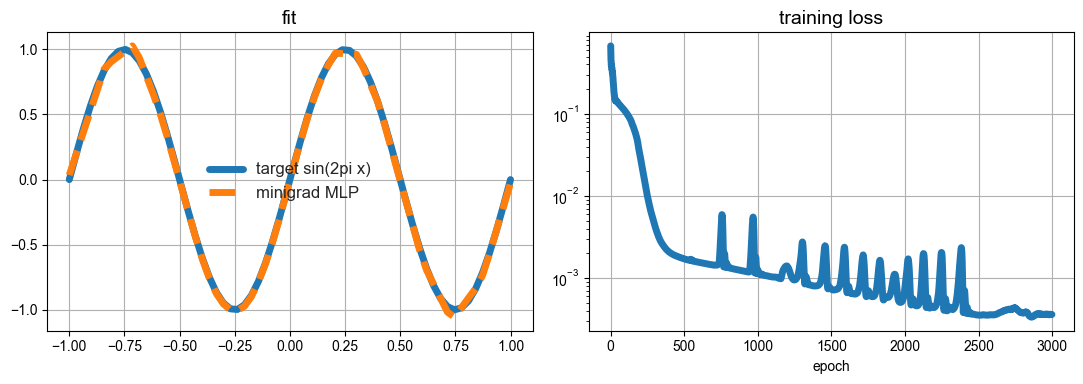

In [27]:
import matplotlib.pyplot as plt

pred = model(X_tensor).data

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

ax[0].plot(X, y, label="target sin(2pi x)", linewidth=5.0)
ax[0].plot(X, pred, "--", label="minigrad MLP", linewidth=5.0)
ax[0].legend()
ax[0].set_title("fit")
ax[0].grid(True)

ax[1].semilogy(losses, linewidth=5.0)
ax[1].set_title("training loss")
ax[1].set_xlabel("epoch")
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 4.2. Classification: two moons

In [28]:
class Softmax(Function):
  """
  See https://eli.thegreenplace.net/2016/the-softmax-function-and-its-derivative/
  """

  @staticmethod
  def forward(ctx: Any, x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - x.max(axis=axis, keepdims=True)
    e = np.exp(z)
    s = e / e.sum(axis=axis, keepdims=True)
    ctx.save_for_backward(s)
    ctx.axis = axis
    return s

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    (s,) = ctx._saved
    return (s * (grad_in - (grad_in * s).sum(axis=ctx.axis, keepdims=True)),)

class CrossEntropy(Function):
  @staticmethod
  def forward(ctx: Any, x: np.ndarray, targets: np.ndarray) -> np.ndarray:
    t = np.asarray(targets).astype(np.int64)
    z = x - x.max(axis=1, keepdims=True) # stability shift
    logsumexp = np.log(np.exp(z).sum(axis=1, keepdims=True))
    logp = z - logsumexp
    n = x.shape[0]
    loss = -logp[np.arange(n), t].mean()
    ctx.save_for_backward(np.exp(logp)) # softmax probs
    ctx.t = t
    ctx.n = n
    return loss

  @staticmethod
  def backward(ctx: Any, grad_in: np.ndarray) -> Tuple[np.ndarray,]:
    (probs,) = ctx._saved
    grad_logits = probs.copy()
    grad_logits[np.arange(ctx.n), ctx.t] -= 1.0 # softmax - onehot
    return (grad_in * grad_logits / ctx.n,)


def cross_entropy(logits: 'Data', targets: 'Data') -> 'Data':
  return CrossEntropy.apply(logits, targets)

In [37]:
def make_moons(n: int, noise: float, seed: int = 0) -> Tuple[np.ndarray, np.ndarray]:
  rng = np.random.default_rng(seed)
  n_out = n // 2
  n_in = n - n_out
  to = np.linspace(0, np.pi, n_out)
  ti = np.linspace(0, np.pi, n_in)
  outer = np.c_[np.cos(to), 1 - np.sin(to) - 0.5]
  inner = np.c_[1 - np.cos(ti), 1 - np.sin(ti) - 0.5]
  X = np.vstack([outer, inner]).astype(np.float64)
  X += noise * rng.standard_normal(X.shape)
  y = np.concatenate([np.zeros(n_out, dtype=np.int64), np.ones(n_in, dtype=np.int64)])
  return X, y

Xc, yc = make_moons(300, noise=0.1, seed=0)

model = MLP([2, 16, 16, 2]) # 2 inputs -> 2 class logits
opt = SGD(model.parameters(), lr=0.1, momentum=0.9)

losses = []
for epoch in range(1000):
  loss = cross_entropy(model(Data(Xc)), Data(yc))
  opt.zero_grad()
  loss.backward()
  opt.step()
  losses.append(loss.data)

<string>:6: RuntimeWarning: divide by zero encountered in matmul
<string>:6: RuntimeWarning: overflow encountered in matmul
<string>:6: RuntimeWarning: invalid value encountered in matmul
<string>:11: RuntimeWarning: divide by zero encountered in matmul
<string>:11: RuntimeWarning: overflow encountered in matmul
<string>:11: RuntimeWarning: invalid value encountered in matmul


<string>:6: RuntimeWarning: divide by zero encountered in matmul
<string>:6: RuntimeWarning: overflow encountered in matmul
<string>:6: RuntimeWarning: invalid value encountered in matmul


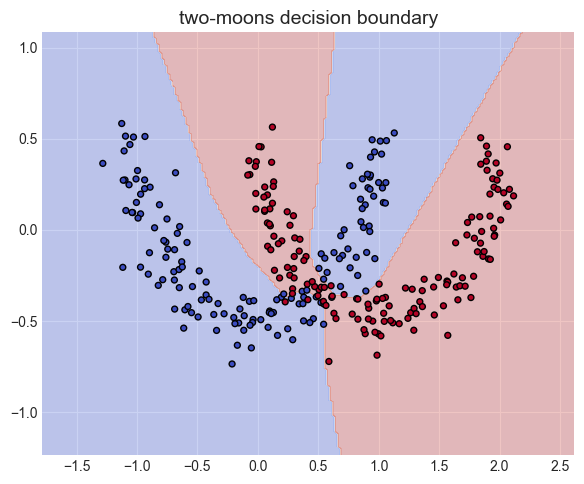

In [38]:
pad = 0.5
xx, yy = np.meshgrid(
    np.linspace(Xc[:, 0].min() - pad, Xc[:, 0].max() + pad, 200),
    np.linspace(Xc[:, 1].min() - pad, Xc[:, 1].max() + pad, 200),
)
zz = model(Data(np.c_[xx.ravel(), yy.ravel()])).data.argmax(1).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=18)
plt.title(f"two-moons decision boundary")
plt.tight_layout()
plt.show()